In [1]:
import numpy as np
import pandas as pd
import csv, os, datetime as dt
import matplotlib.pyplot as plt
import scipy.stats as stats

In [6]:
#Test to see convergence of bob's oversampling of his set U/V

def bob_test_exp(mu1 = 20000, mu2 = 20500, q = 300, k = 8, seed = None):
    rng = np.random.default_rng(seed)
    U = rng.exponential(scale=mu1, size=k)                     # public set, fixed for this run - If you want the same U for every
    V = rng.exponential(scale=mu2, size=k)

    meanU = np.mean(U)
    meanV = np.mean(V)
    
    bob_pick = U if rng.random() < 0.5 else V

    bob_sum = rng.choice(bob_pick, size = q).sum()
    bob_avg = bob_sum/q

    return {
        "Bob's Average": bob_avg,
        "Theoretical mean": meanU if np.array_equal(bob_pick,U) else meanV
    }

In [34]:
#Sweep through several parameters and plot results
def bob_test_sweep(mu1=20000, mu2=20500, q_values=[10, 25, 50, 100, 200, 500, 1000], k=8, seed=None):
    bobAvgLine = []
    bobTheoryLine = []
    for q in q_values:
        result = bob_test_exp(mu1, mu2, q=q, k=k, seed=seed)
        bobAvgLine.append(result["Bob's Average"])
        bobTheoryLine.append(result["Theoretical mean"])

    plt.figure(figsize=(9, 6))

    plt.plot(q_values, bobAvgLine, marker='o', linewidth=2, markersize=6,
              label="Bob's Empirical Average", color='tab:blue')
    plt.plot(q_values, bobTheoryLine, marker='s', linewidth=2, markersize=6,
              linestyle='--', label="Theoretical Mean", color='tab:orange')

    plt.xscale('log')
    plt.xlabel("Sample size (q)", fontsize=12)
    plt.ylabel("Value", fontsize=12)
    plt.title(f"Convergence of Bob's Average vs. Theoretical Mean\n(mu1={mu1}, mu2={mu2}, k={k})",
              fontsize=13, fontweight='bold')

    plt.grid(True, which='both', linestyle=':', alpha=0.6)
    plt.legend(fontsize=11, frameon=True)
    plt.tight_layout()
    plt.show()

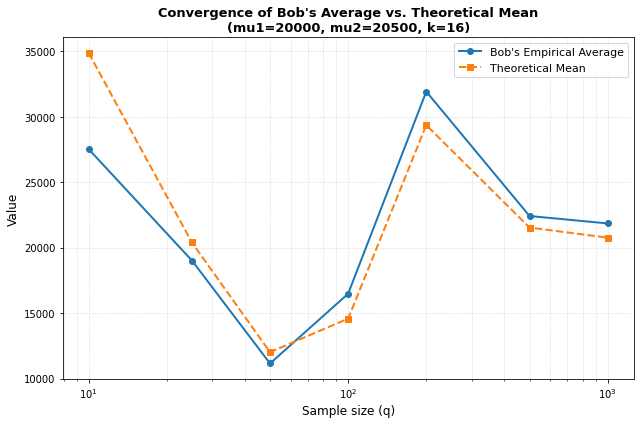

In [39]:
bob_test_sweep(k=16)